# EDA general — más allá de los 3 targets

## Qué preguntas responde este notebook

`04_eda_targets.ipynb` ya mostró cómo se ven las 3 variables que se predicen, y `05_eda_perfil_variables.ipynb` revisó la forma de cada variable candidata por separado. Este notebook empieza a cruzarlas — contra los targets, sobre 2 temporadas completas (2024-2025) — y responde 4 preguntas concretas:

1. **¿La edad y la experiencia de un receptor se relacionan con su producción?**
2. **¿Nuestras features de verdad evitan la fuga de información, con evidencia — no solo porque
   así se diseñaron?**
3. **¿El contexto del partido (línea de Vegas, clima) ayuda a explicar cuánto produce un WR?**

4. **`air_yards_share`/`wopr` a veces salen negativos o mayores a 1 — ¿es un error?**

Se responde cada una con el dato real antes de sacar conclusiones — no se asume nada solo porque
"así lo hace la industria" o "tiene sentido intuitivamente".

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import data, features

sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

SEASONS = [2024, 2025]
stats = data.cargar_stats_semanales(SEASONS)
wr_activo = stats[(stats["position"] == "WR") & (stats["targets"] > 0)].copy()
jugadores = data.cargar_jugadores()
print("filas WR activas (targets > 0):", wr_activo.shape[0])

filas WR activas (targets > 0): 4187


## 1. Edad y experiencia

Se calcula la edad de cada jugador al 1 de septiembre de la temporada correspondiente (misma
convención que se usa en `preeliminar/03_modelo_predictivo`, para poder comparar criterios), y
los años de experiencia como `temporada - temporada de novato`.

In [2]:
wr_j = wr_activo.merge(
    jugadores[["gsis_id", "birth_date", "rookie_season"]],
    left_on="player_id", right_on="gsis_id", how="left"
)
ref = pd.to_datetime(wr_j["season"].astype(str) + "-09-01")
wr_j["edad"] = (ref - wr_j["birth_date"]).dt.days / 365.25
wr_j["anios_experiencia"] = wr_j["season"] - wr_j["rookie_season"]

print("cobertura de birth_date/rookie_season:", wr_j["birth_date"].notna().mean(), "/", wr_j["rookie_season"].notna().mean())
print(wr_j["edad"].describe()[["mean", "min", "max"]])
print()
print("correlacion (lineal) edad vs yardas:", round(wr_j["edad"].corr(wr_j["receiving_yards"]), 3))
print("correlacion (lineal) experiencia vs yardas:", round(wr_j["anios_experiencia"].corr(wr_j["receiving_yards"]), 3))

cobertura de birth_date/rookie_season: 1.0 / 1.0
mean    26.188888
min     21.097878
max     35.028063
Name: edad, dtype: float64

correlacion (lineal) edad vs yardas: -0.053
correlacion (lineal) experiencia vs yardas: 0.011


Ambas correlaciones lineales salen prácticamente en cero. **La primera tentación sería concluir
"la experiencia no importa" — pero antes de aceptar eso, conviene mirar más allá de una sola
correlación**, que solo detecta relaciones en línea recta.

            receptions  receiving_yards  receiving_tds
exp_bucket                                            
Rookie        2.359690        29.750388       0.204651
1-2 años      2.992107        37.844515       0.243883
3-5 años      3.408938        44.365093       0.279089
6+ años       2.863177        34.139578       0.215794


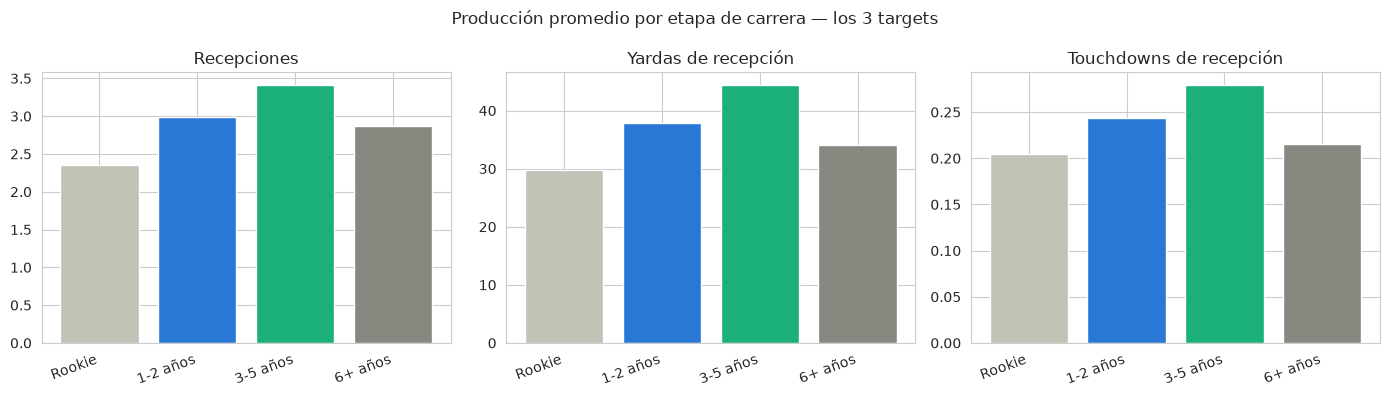

In [3]:
bins = [-1, 0, 2, 5, 100]
labels = ["Rookie", "1-2 años", "3-5 años", "6+ años"]
wr_j["exp_bucket"] = pd.cut(wr_j["anios_experiencia"], bins=bins, labels=labels)
resumen_exp = wr_j.groupby("exp_bucket", observed=True)[["receptions", "receiving_yards", "receiving_tds"]].mean()
print(resumen_exp)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colores = [GRIS_CLARO, AZUL, VERDE, GRIS]
for ax, col, titulo in zip(axes, ["receptions", "receiving_yards", "receiving_tds"],
                            ["Recepciones", "Yardas de recepción", "Touchdowns de recepción"]):
    ax.bar(resumen_exp.index.astype(str), resumen_exp[col], color=colores)
    ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.suptitle("Producción promedio por etapa de carrera — los 3 targets")
plt.tight_layout()
plt.show()

**Ahí está lo que la correlación lineal no dejaba ver, y se repite en los 3 targets, no solo yardas**: recepciones (2.36 → 2.99 → **3.41 pico** → 2.86), yardas (29.8 → 37.8 → **44.4 pico** → 34.1) y touchdowns (0.20 → 0.24 → **0.28 pico** → 0.22) — los 3 suben de novato hasta 3-5 años de experiencia, y los 3 bajan después. No es un patrón exclusivo de las yardas — es la forma real de la curva de carrera de un receptor, y una correlación lineal la esconde en los 3 casos por igual, no solo en uno.

Verificación sistemática de esto y de muchas más variables (no solo edad) en [`08_eda_multivariable.ipynb`](08_eda_multivariable.ipynb) — ese notebook confirma el mismo patrón de forma más rigurosa, junto con hallazgos nuevos (`draft_pick`, cambios de quarterback, multicolinealidad entre features) que no se habían visto en este notebook.

## 2. `air_yards_share`/`wopr` negativos o mayores a 1 — ¿error o algo real?

Antes de graficar estas dos columnas (candidatas a feature), llama la atención que el mínimo y
el máximo se salen del rango [0, 1] que "share" sugiere. Se verifica con el caso real más extremo
antes de decidir si son datos rotos.

In [4]:
print(wr_activo[["target_share", "air_yards_share", "wopr"]].describe().loc[["min", "max"]])

     target_share  air_yards_share      wopr
min      0.017544        -0.423077 -0.100502
max      0.666667         1.315789  1.518851


¿Qué pasa en la fila con el `air_yards_share` más negativo?

In [5]:
caso = wr_activo.nsmallest(1, "air_yards_share").iloc[0]
print(caso[["player_display_name", "season", "week", "team", "receiving_air_yards", "air_yards_share"]])

equipo_semana = stats[
    (stats["team"] == caso["team"]) & (stats["season"] == caso["season"]) & (stats["week"] == caso["week"])
]
total_equipo = equipo_semana["receiving_air_yards"].sum()
print()
print(f"total de yardas aereas de TODO el equipo esa semana: {total_equipo}")
print(f"{caso['player_display_name']}: {caso['receiving_air_yards']} / {total_equipo} = "
      f"{caso['receiving_air_yards'] / total_equipo:.3f}")

player_display_name    Marvin Mims Jr.
season                            2025
week                                18
team                               DEN
receiving_air_yards                -11
air_yards_share              -0.423077
Name: 36306, dtype: object

total de yardas aereas de TODO el equipo esa semana: 26
Marvin Mims Jr.: -11 / 26 = -0.423


**No es un error.** El total de yardas aéreas de todo el equipo esa semana fue pequeño (varios
compañeros con pases cortos o de retroceso, que suman negativo entre todos) — dividir un valor
individual entre un total pequeño y volátil puede dar una "participación" fuera de [0, 1] sin que
nada esté mal calculado. Es aritmética correcta sobre un denominador inusual, no un dato corrupto
como los que sí se encontraron en el archivo de ADP. **Acción**: se documenta el porqué, se usa
la columna tal cual — no hay nada que limpiar.

## 3. ¿Nuestras features evitan la fuga, con evidencia?

Se repite exactamente la prueba que ya se usó en `preeliminar/03_modelo_predictivo/01_eda_para_modelado.ipynb`:
comparar la correlación de `target_share` **de la misma semana** que se quiere predecir (que por
construcción ya "sabe" el resultado, es circular) contra la versión correctamente rezagada que
sí usa `features.py`.

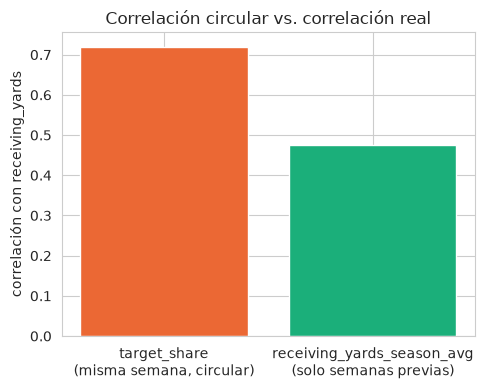

sin rezago (circular): 0.720
con rezago (lo que de verdad usa el pipeline): 0.474


In [6]:
corr_sin_rezago = wr_activo[["target_share", "receiving_yards"]].corr().iloc[0, 1]

con_features = features.agregar_promedios_jugador(wr_activo, ["receiving_yards"], id_col="player_id")
corr_con_rezago = con_features[["receiving_yards_season_avg", "receiving_yards"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["target_share\n(misma semana, circular)", "receiving_yards_season_avg\n(solo semanas previas)"],
    [corr_sin_rezago, corr_con_rezago],
    color=[NARANJA, VERDE],
)
ax.set_ylabel("correlación con receiving_yards")
ax.set_title("Correlación circular vs. correlación real")
plt.tight_layout()
plt.show()

print(f"sin rezago (circular): {corr_sin_rezago:.3f}")
print(f"con rezago (lo que de verdad usa el pipeline): {corr_con_rezago:.3f}")

La correlación circular (0.72) es más alta que la real (0.47) — como se espera, porque la
versión circular ya conoce en parte el resultado que se quiere predecir. `features.py` usa
exclusivamente la versión rezagada (0.47): más baja, pero es la que de verdad se podría calcular
*antes* de que se juegue el partido. Esta misma prueba, con el mismo tipo de resultado (una caída
real al rezagar), es la que Daniel documentó en su propia exploración previa — aquí se repite
sobre datos nuevos (`nflreadpy`) para confirmar que la disciplina de rezago sigue sosteniéndose.

## 4. ¿Vegas y el clima ayudan a explicar la producción de un WR?

Ya se había probado esto de forma exploratoria antes en el proyecto (documentado en el Datasheet
y el ADR `0002-fuente-de-datos.md`) — aquí se formaliza con código real en el repo, sobre los
datos actuales de `nflreadpy`. Se construye el "total implícito de equipo" (lo que el mercado de
apuestas espera que anote el equipo del jugador, derivado de `spread_line`/`total_line`).

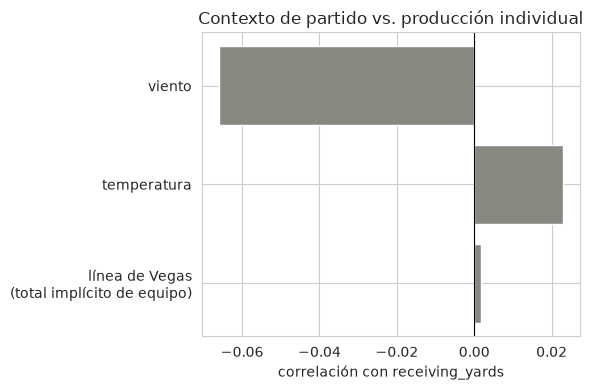

línea de Vegas
(total implícito de equipo): 0.0018
temperatura: 0.0229
viento: -0.0660


In [7]:
calendario = data.cargar_calendario(SEASONS)
cal_home = calendario[["season", "week", "home_team", "spread_line", "total_line", "temp", "wind"]].rename(columns={"home_team": "team"})
cal_away = calendario[["season", "week", "away_team", "spread_line", "total_line", "temp", "wind"]].rename(columns={"away_team": "team"})
cal_home["team_implied_total"] = (cal_home["total_line"] - cal_home["spread_line"]) / 2
cal_away["team_implied_total"] = (cal_away["total_line"] + cal_away["spread_line"]) / 2
cal_long = pd.concat([cal_home, cal_away], ignore_index=True)

wr_vegas = wr_activo.merge(cal_long, on=["season", "week", "team"], how="left")

corrs = {
    "línea de Vegas\n(total implícito de equipo)": wr_vegas["team_implied_total"].corr(wr_vegas["receiving_yards"]),
    "temperatura": wr_vegas["temp"].corr(wr_vegas["receiving_yards"]),
    "viento": wr_vegas["wind"].corr(wr_vegas["receiving_yards"]),
}
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(corrs.keys()), list(corrs.values()), color=GRIS)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("correlación con receiving_yards")
ax.set_title("Contexto de partido vs. producción individual")
plt.tight_layout()
plt.show()

for k, v in corrs.items():
    print(f"{k}: {v:.4f}")

Las 3 correlaciones son prácticamente cero — ni siquiera 0.07 en el peor caso (viento). Confirma,
ahora con código propio en este repo (antes solo se había probado suelto), la hipótesis que ya se
documentó: el contexto de partido no aporta señal individual real para un WR — probablemente
porque el uso reciente del jugador (`target_share`, `receiving_yards_last5/last3`) ya captura
implícitamente el "guión del partido" mejor de lo que lo hace una línea de apuestas genérica.
**Se documenta la evidencia de que no ayuda; no se agrega a `features.py` sin una razón nueva.**

## Cierre

- La experiencia sí importa, pero no de forma lineal — sube y luego baja (pico en 3-5 años). Una
  correlación simple no lo detecta; vale la pena mantener `anios_experiencia` como feature para
  un modelo que sí capture curvas, no descartarla por una correlación cercana a cero.
- `air_yards_share`/`wopr` pueden salir negativos o mayores a 1 — verificado con un caso real
  (Marvin Mims Jr., -11 de 26 yardas aéreas totales del equipo esa semana = -0.42): es aritmética
  correcta cuando el total del equipo es pequeño, no un error de datos.
- La disciplina de rezago de `features.py` se sostiene con evidencia (0.72 circular → 0.47 real),
  repitiendo la misma prueba que ya se usó en `preeliminar`.
- Vegas y clima siguen sin aportar señal individual real para WR — confirmado ahora con código
  propio, no solo una prueba suelta.

Notebook anterior: [`05_eda_perfil_variables.ipynb`](05_eda_perfil_variables.ipynb) · Siguiente: [`07_eda_equipos.ipynb`](07_eda_equipos.ipynb)